In [ ]:

# CELL 1 — Mount google drive

from google.colab import drive
drive.mount('/content/drive')

!pip install kaggle pandas numpy pyarrow tqdm -q

import os
import json
import ast
import numpy as np
import pandas as pd
from tqdm import tqdm

print("Drive mounted, packages installed.")


Mounted at /content/drive
Drive mounted, packages installed.


In [ ]:
# CELL 2 — Dataset download

from google.colab import files
uploaded = files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d tientd95/fitrec-dataset -q
!unzip -q fitrec-dataset.zip

!ls -lh *.json


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/tientd95/fitrec-dataset
License(s): unknown
-rw-r--r-- 1 root root 6.2G Aug 13  2020 endomondoHR.json
-rw-r--r-- 1 root root   62 Feb 21 15:27 kaggle.json


In [ ]:

# CELL 3 — Parameters and output paths defined


# Sampling
MAX_RIDES_PER_CYCLIST = 50
MIN_RIDE_DURATION_POINTS = 360

# Resampling
RESAMPLE_SECONDS = 5
MIN_RIDE_LENGTH_AFTER_RESAMPLE = 360  # 30 min at 5s

# Relax interpolation controls
MAX_INTERP_GAP_SECONDS = 180
MAX_INTERP_STEPS = max(1, MAX_INTERP_GAP_SECONDS // RESAMPLE_SECONDS)

# Relax missingness filter
MAX_NAN_FRACTION = 0.50

# HR sanity
HR_MIN = 30
HR_MAX = 220

# Speed sanity
SPEED_MIN = 0
SPEED_MAX = None

OUTPUT_DIR = "/content/drive/MyDrive/fitrec_processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Will sample up to {MAX_RIDES_PER_CYCLIST} rides per cyclist")
print(f"Resample: {RESAMPLE_SECONDS}s | Min length: {MIN_RIDE_LENGTH_AFTER_RESAMPLE} rows")
print(f"Max interpolation gap: {MAX_INTERP_GAP_SECONDS}s (={MAX_INTERP_STEPS} steps)")
print(f"Max NaN fraction allowed (post-resample): {MAX_NAN_FRACTION}")


Will sample up to 50 rides per cyclist
Resample: 5s | Min length: 360 rows
Max interpolation gap: 180s (=36 steps)
Max NaN fraction allowed (post-resample): 0.5


In [ ]:
=
# CELL 4 — Metadata scan


json_path = "/content/endomondoHR.json"
TOTAL_LINES = 253020

metadata = []

def compute_duration_minutes(ts, fallback_points, approx_step_sec=5):
    """
    Prefer epoch-based duration if timestamps look like unix seconds.
    Otherwise fall back to approx points * 5 sec.
    """
    try:
        if isinstance(ts, list) and len(ts) >= 2 and ts[0] is not None:
            if ts[0] > 1_000_000_000 and ts[-1] > 1_000_000_000:
                dur = (ts[-1] - ts[0]) / 60.0
                if np.isfinite(dur) and dur > 0:
                    return float(dur)
        return float(fallback_points * approx_step_sec / 60.0)
    except Exception:
        return float(fallback_points * approx_step_sec / 60.0)

print("Scanning metadata (this takes a while)...")
with open(json_path, 'r') as f:
    for line_num, line in tqdm(enumerate(f), total=TOTAL_LINES, desc="Metadata scan"):
        try:
            record = ast.literal_eval(line.strip())

            sport = str(record.get('sport', '')).lower()
            if sport != 'bike':
                continue

            hr = record.get('heart_rate', [])
            sp = record.get('speed', [])

            hr_count = len(hr) if isinstance(hr, list) else 0
            speed_count = len(sp) if isinstance(sp, list) else 0

            if hr_count >= MIN_RIDE_DURATION_POINTS and speed_count >= MIN_RIDE_DURATION_POINTS:
                user_id = record.get('userId')
                gender = record.get('gender', 'unknown')
                ride_length = min(hr_count, speed_count)

                ts = record.get('timestamp', [])
                duration_minutes = compute_duration_minutes(ts, ride_length, approx_step_sec=5)

                metadata.append({
                    'line_num': line_num,
                    'userId': user_id,
                    'gender': gender,
                    'hr_count': hr_count,
                    'speed_count': speed_count,
                    'ride_length': ride_length,
                    'duration_minutes': duration_minutes
                })
        except Exception:
            pass

metadata_df = pd.DataFrame(metadata)
print(f"\n Found {len(metadata_df)} eligible bike rides (≥ ~30 min)")
print(f"   Unique cyclists: {metadata_df['userId'].nunique()}")


Scanning metadata (this takes a while)...


Metadata scan: 100%|██████████| 253020/253020 [37:00<00:00, 113.97it/s]



 Found 20546 eligible bike rides (≥ ~30 min)
   Unique cyclists: 535


In [ ]:

# CELL 5 — Sample rides per cyclist and then save indices

sampled_lines = []

for user_id, group in metadata_df.groupby('userId'):
    if len(group) > MAX_RIDES_PER_CYCLIST:
        sampled = group.sample(n=MAX_RIDES_PER_CYCLIST, random_state=42)
    else:
        sampled = group
    sampled_lines.extend(sampled['line_num'].tolist())

print(f"Selected {len(sampled_lines)} rides for cleaning (max {MAX_RIDES_PER_CYCLIST} per cyclist)")

sampled_indices_df = pd.DataFrame({'line_num': sampled_lines})
sampled_indices_path = os.path.join(OUTPUT_DIR, "sampled_indices.parquet")
sampled_indices_df.to_parquet(sampled_indices_path, index=False)
print(f" Saved sampled indices to: {sampled_indices_path}")


Selected 11632 rides for cleaning (max 50 per cyclist)
✅ Saved sampled indices to: /content/drive/MyDrive/fitrec_processed/sampled_indices.parquet


In [ ]:

# CELL 6 — Cleaning function


def clean_one_ride(rec):
    try:
        hr  = rec.get('heart_rate', [])
        sp  = rec.get('speed', [])
        ts  = rec.get('timestamp', list(range(len(hr))))
        alt = rec.get('altitude', [0] * len(hr))

        # gps arrays
        lat = rec.get('latitude',  [np.nan] * len(hr))
        lon = rec.get('longitude', [np.nan] * len(hr))

        if not isinstance(hr, list) or len(hr) < 20:
            return None

        # Ensure all arrays align safely
        n = min(len(ts), len(hr), len(sp), len(alt), len(lat), len(lon))
        if n < 20:
            return None

        df = pd.DataFrame({
            'timestamp': ts[:n],
            'hr': hr[:n],
            'speed': sp[:n],
            'altitude': alt[:n],
            'latitude': lat[:n],
            'longitude': lon[:n]
        })

        # Basic sanity filters
        df = df[(df['hr'] > 0) & (df['hr'] < HR_MAX)]
        df = df[df['speed'] >= SPEED_MIN]
        if SPEED_MAX is not None:
            df = df[df['speed'] <= SPEED_MAX]

        if len(df) < 20:
            return None

        # IQR outlier removal on HR only
        Q1, Q3 = df['hr'].quantile(0.25), df['hr'].quantile(0.75)
        iqr = Q3 - Q1
        df = df[(df['hr'] >= Q1 - 1.5*iqr) & (df['hr'] <= Q3 + 1.5*iqr)]
        if len(df) < 20:
            return None

        # Timestamp handling
        try:
            first_ts = df['timestamp'].iloc[0]
            if pd.notna(first_ts) and first_ts > 1_000_000_000:
                df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s', errors='coerce')
            else:
                df['timestamp'] = pd.to_timedelta(df['timestamp'], unit='s', errors='coerce')
        except Exception:
            df['timestamp'] = pd.to_timedelta(range(len(df)), unit='s')

        df = df.dropna(subset=['timestamp'])
        if len(df) < 20:
            return None

        df = df.sort_values('timestamp').reset_index(drop=True)
        df = df.set_index('timestamp')

        # Resample
        df = df.resample(f'{RESAMPLE_SECONDS}S').mean()

        #  Missingness check
        nan_frac_core = df[['hr', 'speed', 'altitude']].isna().mean().max()
        if nan_frac_core > MAX_NAN_FRACTION:
            return None

        # Interpolate small gaps only
        df = df.interpolate('linear', limit=MAX_INTERP_STEPS)

        # Fills remaining gaps so we don't drop rides
        df = df.ffill().bfill()

        # Reset index back to column
        df = df.reset_index()


        df = df[(df['hr'] >= HR_MIN) & (df['hr'] < HR_MAX)]
        if len(df) < MIN_RIDE_LENGTH_AFTER_RESAMPLE:
            return None


        try:
            df['elapsed_seconds'] = (df['timestamp'] - df['timestamp'].iloc[0]).dt.total_seconds()
        except Exception:
            df['elapsed_seconds'] = np.arange(len(df)) * RESAMPLE_SECONDS

        # IDs / metadata
        df['cyclist_id'] = rec.get('userId')
        df['gender'] = rec.get('gender', 'unknown')
        df['ride_id'] = rec.get('id')

        return df

    except Exception:
        return None


In [ ]:

# CELL 7 — Load only sampled lines and then clean

lines_to_read = set(sampled_lines)

cleaned_rides_list = []
failed = 0

print(f"Loading and cleaning {len(lines_to_read)} sampled rides...")
with open(json_path, 'r') as f:
    for line_num, line in tqdm(enumerate(f), total=TOTAL_LINES, desc="Cleaning"):
        if line_num in lines_to_read:
            try:
                record = ast.literal_eval(line.strip())
                cleaned = clean_one_ride(record)
                if cleaned is not None:
                    cleaned_rides_list.append(cleaned)
                else:
                    failed += 1
            except Exception:
                failed += 1

print(f"\n Successfully cleaned {len(cleaned_rides_list)} rides")
print(f"   Failed: {failed}")

if not cleaned_rides_list:
    raise RuntimeError("No rides were cleaned successfully!")

all_rides_df = pd.concat(cleaned_rides_list, ignore_index=True)
print(f"   Total resampled rows: {len(all_rides_df)}")


Loading and cleaning 11632 sampled rides...


Streaming output truncated to the last 5000 lines.
/tmp/ipython-input-812322734.py:71: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df = df.resample(f'{RESAMPLE_SECONDS}S').mean()
/tmp/ipython-input-812322734.py:71: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df = df.resample(f'{RESAMPLE_SECONDS}S').mean()
/tmp/ipython-input-812322734.py:71: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df = df.resample(f'{RESAMPLE_SECONDS}S').mean()
/tmp/ipython-input-812322734.py:71: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df = df.resample(f'{RESAMPLE_SECONDS}S').mean()
/tmp/ipython-input-812322734.py:71: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df = df.resample(f'{RESAMPLE_SECONDS}S').mean()
/tmp/ipython-input-812322734.


✅ Successfully cleaned 3535 rides
   Failed: 8097
   Total resampled rows: 2316019


In [ ]:

# CELL 8 — Saves parquet outputs

sampled_rides_path = os.path.join(OUTPUT_DIR, "sampled_rides.parquet")
all_rides_df.to_parquet(sampled_rides_path, index=False)
print(f" Saved all cleaned sampled rides to: {sampled_rides_path}")

metadata_path = os.path.join(OUTPUT_DIR, "metadata.parquet")
metadata_df.to_parquet(metadata_path, index=False)
print(f" Saved metadata to: {metadata_path}")


✅ Saved all cleaned sampled rides to: /content/drive/MyDrive/fitrec_processed/sampled_rides.parquet
✅ Saved metadata to: /content/drive/MyDrive/fitrec_processed/metadata.parquet


In [ ]:

# CELL 9 — Verification and sample rows

print("\n VERIFICATION")
print(f"Total unique cyclists in sampled rides: {all_rides_df['cyclist_id'].nunique()}")
print(f"Total rides: {all_rides_df['ride_id'].nunique()}")
print(f"Total rows: {len(all_rides_df)}")
print(f"Sampling rate: {RESAMPLE_SECONDS} sec")

ride_sizes = all_rides_df.groupby('ride_id').size()
print(f"Ride duration range: {ride_sizes.min() * RESAMPLE_SECONDS / 60:.1f} – {ride_sizes.max() * RESAMPLE_SECONDS / 60:.1f} min")

sample_ride_id = all_rides_df['ride_id'].iloc[0]
sample = all_rides_df[all_rides_df['ride_id'] == sample_ride_id].head()
print("\nSample ride (first 5 rows):")
cols = ['timestamp', 'elapsed_seconds', 'hr', 'speed', 'cyclist_id']
print(sample[cols])



=== VERIFICATION ===
Total unique cyclists in sampled rides: 422
Total rides: 3535
Total rows: 2316019
Sampling rate: 5 sec
Ride duration range: 30.0 – 83.0 min

Sample ride (first 5 rows):
            timestamp  elapsed_seconds     hr    speed  cyclist_id
0 2014-08-16 20:42:00              0.0  126.0  34.8372    10921915
1 2014-08-16 20:42:05              5.0  130.0  42.8436    10921915
2 2014-08-16 20:42:10             10.0  132.0  41.7852    10921915
3 2014-08-16 20:42:15             15.0  134.0  39.6612    10921915
4 2014-08-16 20:42:20             20.0  136.0  34.5114    10921915


In [ ]:
# Cell 10
ride_stats = all_rides_df.groupby("ride_id").agg(
    duration_min=("elapsed_seconds", lambda x: x.max()/60),
    hr_mean=("hr","mean"),
    hr_std=("hr","std"),
    speed_mean=("speed","mean"),
    cyclist=("cyclist_id","first")
)

ride_stats.describe()


,duration_min,hr_mean,hr_std,speed_mean,cyclist
count,3535.000000,3535.000000,3535.000000,3535.000000,3.535000e+03
mean,54.514003,138.534418,11.321134,26.019765,5.052658e+06
std,13.535387,16.590766,5.020368,5.937803,4.022522e+06
min,29.916667,76.852632,1.392050,0.000000,2.358000e+03
25%,42.916667,128.181525,7.772275,22.685506,1.842744e+06
50%,55.666667,138.902906,10.701509,26.449900,3.841089e+06
75%,65.000000,149.720224,14.237645,29.853200,7.696046e+06
max,82.916667,207.069853,38.549525,57.971444,1.454427e+07


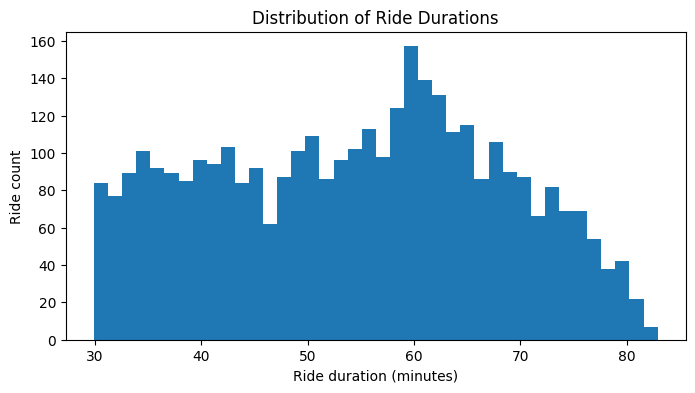

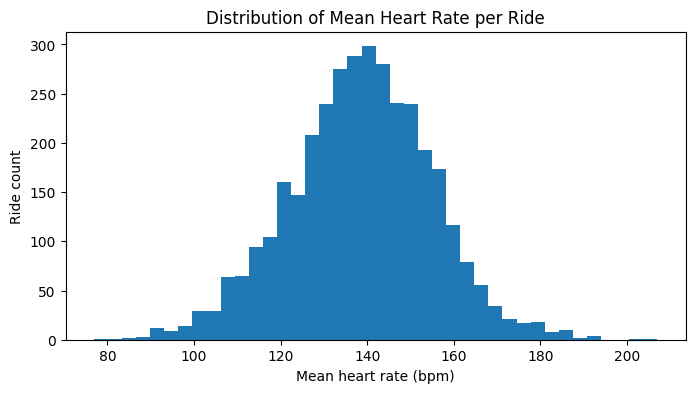

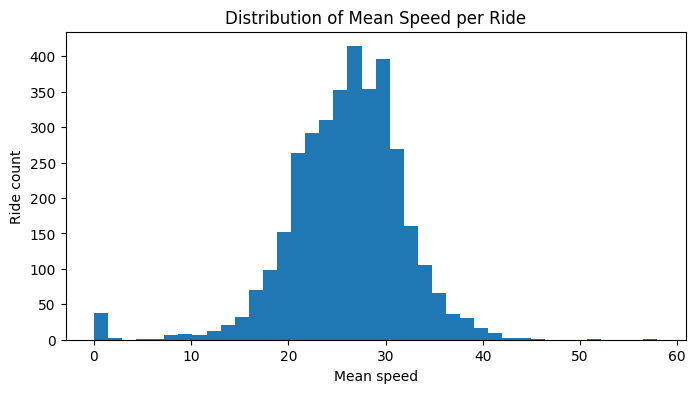

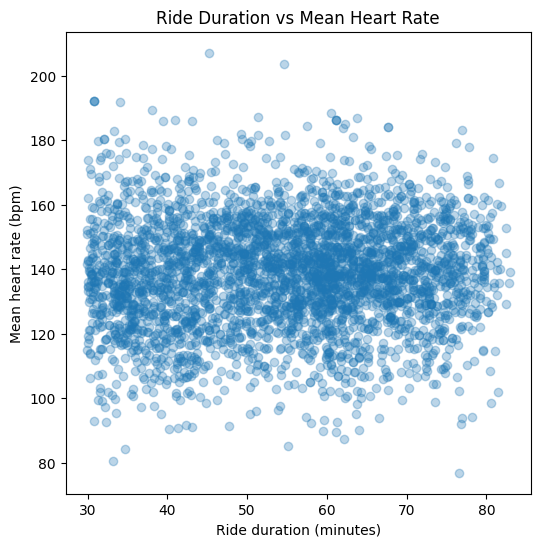

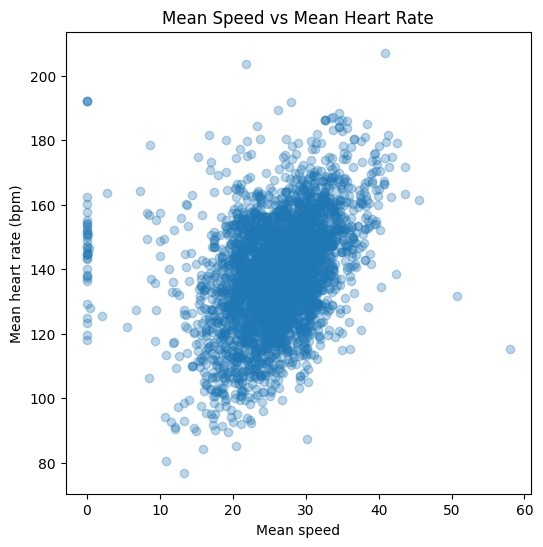

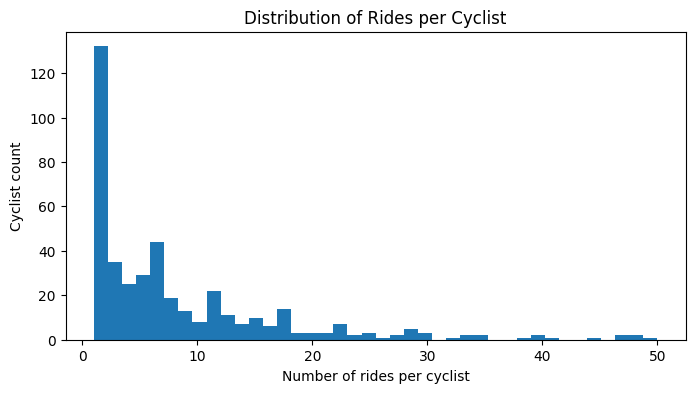

Summary:
Total cyclists: 422
Median rides per cyclist: 5
Max rides per cyclist: 50


In [ ]:
# Cell 11
import matplotlib.pyplot as plt

# 1) Ride duration histogram
plt.figure(figsize=(8,4))
plt.hist(ride_stats["duration_min"], bins=40)
plt.xlabel("Ride duration (minutes)")
plt.ylabel("Ride count")
plt.title("Distribution of Ride Durations")
plt.show()

# 2) Mean HR distribution
plt.figure(figsize=(8,4))
plt.hist(ride_stats["hr_mean"], bins=40)
plt.xlabel("Mean heart rate (bpm)")
plt.ylabel("Ride count")
plt.title("Distribution of Mean Heart Rate per Ride")
plt.show()


# 3) Mean speed distribution
plt.figure(figsize=(8,4))
plt.hist(ride_stats["speed_mean"], bins=40)
plt.xlabel("Mean speed")
plt.ylabel("Ride count")
plt.title("Distribution of Mean Speed per Ride")
plt.show()


# 4) Duration vs Mean HR scatter
plt.figure(figsize=(6,6))
plt.scatter(ride_stats["duration_min"], ride_stats["hr_mean"], alpha=0.3)
plt.xlabel("Ride duration (minutes)")
plt.ylabel("Mean heart rate (bpm)")
plt.title("Ride Duration vs Mean Heart Rate")
plt.show()


# 5) Mean speed vs Mean HR scatter
plt.figure(figsize=(6,6))
plt.scatter(ride_stats["speed_mean"], ride_stats["hr_mean"], alpha=0.3)
plt.xlabel("Mean speed")
plt.ylabel("Mean heart rate (bpm)")
plt.title("Mean Speed vs Mean Heart Rate")
plt.show()


# 6) Per-cyclist ride count histogram
rides_per_cyclist = ride_stats.groupby("cyclist").size()

plt.figure(figsize=(8,4))
plt.hist(rides_per_cyclist, bins=40)
plt.xlabel("Number of rides per cyclist")
plt.ylabel("Cyclist count")
plt.title("Distribution of Rides per Cyclist")
plt.show()


print("Summary:")
print("Total cyclists:", ride_stats["cyclist"].nunique())
print("Median rides per cyclist:", int(rides_per_cyclist.median()))
print("Max rides per cyclist:", int(rides_per_cyclist.max()))


In [ ]:
# Cell 12
print(all_rides_df.columns)

Index(['timestamp', 'hr', 'speed', 'altitude', 'latitude', 'longitude',
       'elapsed_seconds', 'cyclist_id', 'gender', 'ride_id'],
      dtype='object')
